In [5]:
# ============================================================
# BLOCK 1 — DOWNLOAD & LOAD AMES HOUSE PRICES DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

print("=" * 65)
print("HOUSE PRICE PREDICTION — AMES HOUSING DATASET")
print("=" * 65)

# Download Ames Housing / House Prices dataset automatically
housing = fetch_openml(
    name="house_prices",
    as_frame=True,
    parser="auto"
)

# Create dataframe
df = housing.frame.copy()

print("\n✅ Dataset downloaded successfully!")

print(f"\nRows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nFirst 5 records:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nTarget variable:")
print("SalePrice")

print("\nTarget statistics:")
display(df["SalePrice"].describe())

HOUSE PRICE PREDICTION — AMES HOUSING DATASET

✅ Dataset downloaded successfully!

Rows    : 1460
Columns : 81

First 5 records:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


AMES HOUSING DATASET — EXPLORATORY DATA ANALYSIS

📌 Dataset Shape
Rows    : 1460
Columns : 81

📌 Data Types
Numerical features   : 38
Categorical features : 43

📌 Missing Values


,Missing Values,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageCond,81,5.547945
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945



📌 Duplicate Records
Duplicate rows: 0

📌 Target Variable — SalePrice


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


Minimum Price : $34,900.00
Maximum Price : $755,000.00
Mean Price    : $180,921.20
Median Price  : $163,000.00


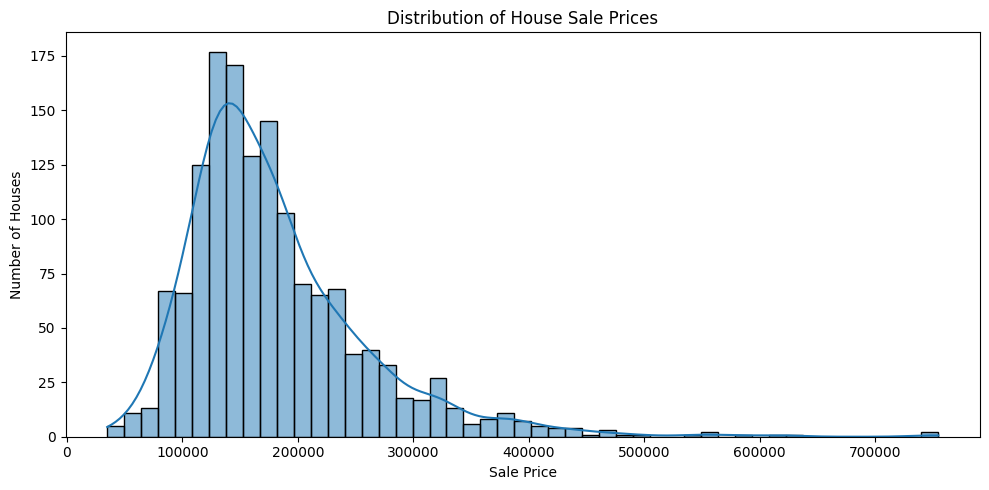


📌 Top Features Correlated with SalePrice


,Correlation with SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


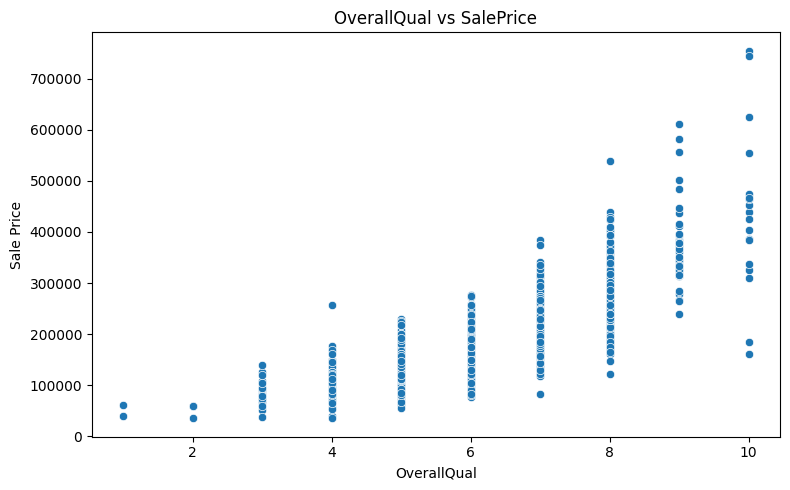

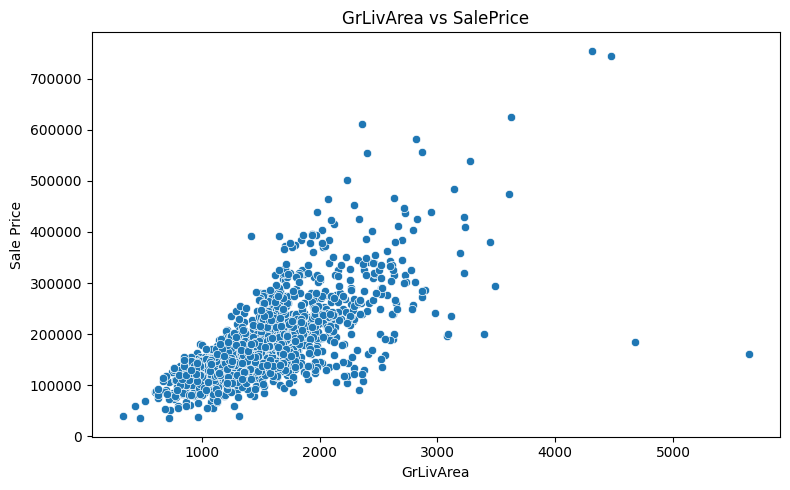

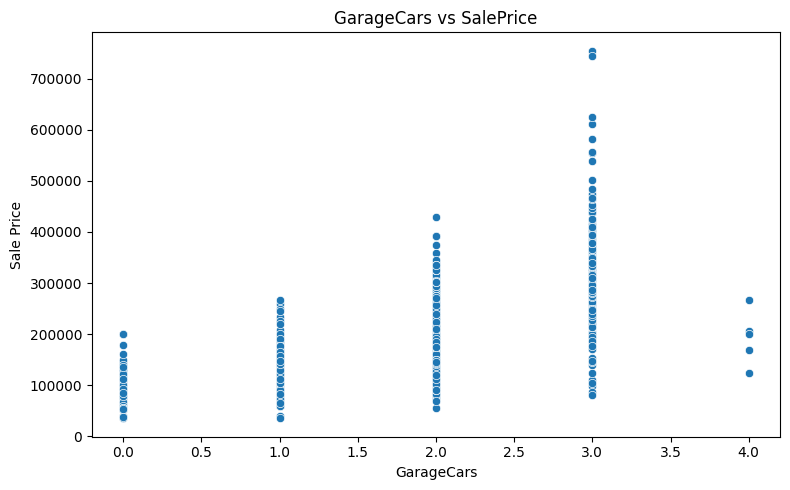

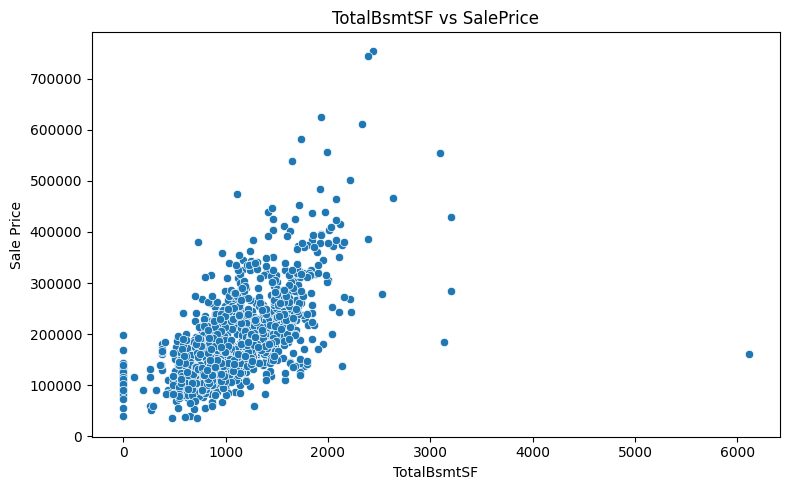

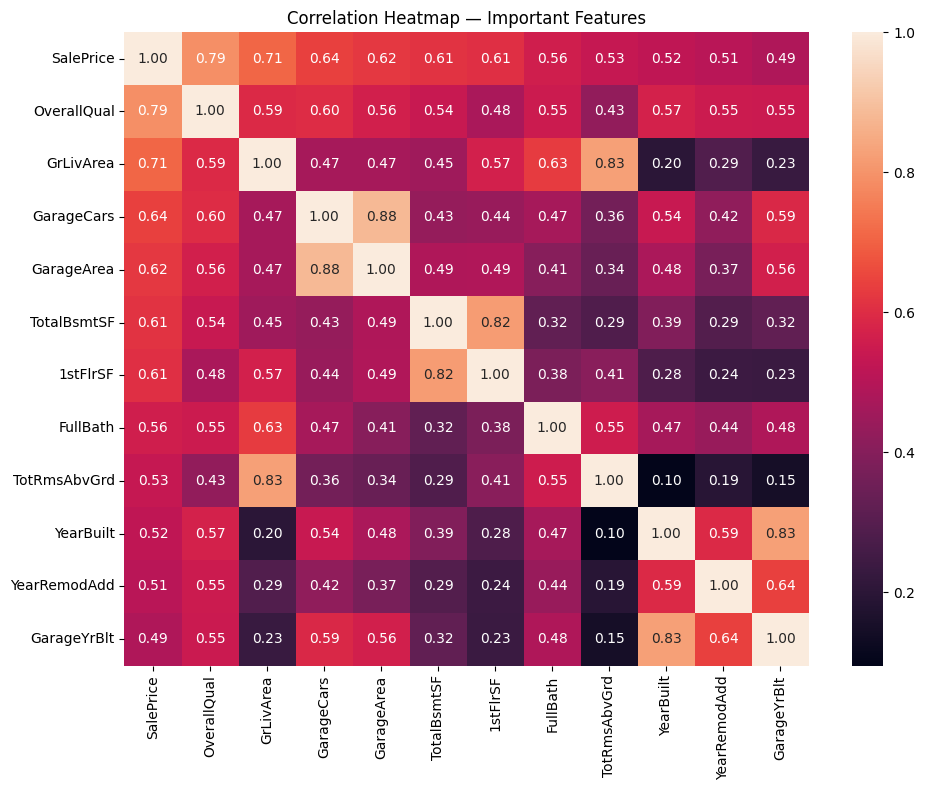


EDA COMPLETED ✅


In [6]:
# ============================================================
# BLOCK 2 — DATASET UNDERSTANDING & EDA
# ============================================================

print("=" * 65)
print("AMES HOUSING DATASET — EXPLORATORY DATA ANALYSIS")
print("=" * 65)

# ------------------------------------------------------------
# 1. Dataset shape
# ------------------------------------------------------------

print("\n📌 Dataset Shape")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


# ------------------------------------------------------------
# 2. Data types
# ------------------------------------------------------------

print("\n📌 Data Types")

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print(f"Numerical features   : {len(numeric_columns)}")
print(f"Categorical features : {len(categorical_columns)}")


# ------------------------------------------------------------
# 3. Missing values
# ------------------------------------------------------------

print("\n📌 Missing Values")

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_df = missing_df[
    missing_df["Missing Values"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_df.head(20))


# ------------------------------------------------------------
# 4. Duplicate records
# ------------------------------------------------------------

print("\n📌 Duplicate Records")
print(f"Duplicate rows: {df.duplicated().sum()}")


# ------------------------------------------------------------
# 5. Target variable
# ------------------------------------------------------------

print("\n📌 Target Variable — SalePrice")

display(df["SalePrice"].describe())

print(f"Minimum Price : ${df['SalePrice'].min():,.2f}")
print(f"Maximum Price : ${df['SalePrice'].max():,.2f}")
print(f"Mean Price    : ${df['SalePrice'].mean():,.2f}")
print(f"Median Price  : ${df['SalePrice'].median():,.2f}")


# ------------------------------------------------------------
# 6. SalePrice distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Top numerical correlations
# ------------------------------------------------------------

numeric_df = df.select_dtypes(include=np.number)

correlations = (
    numeric_df
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

print("\n📌 Top Features Correlated with SalePrice")

display(
    correlations
    .head(11)
    .to_frame("Correlation with SalePrice")
)


# ------------------------------------------------------------
# 8. Important feature relationships
# ------------------------------------------------------------

important_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF"
]

available_features = [
    feature
    for feature in important_features
    if feature in df.columns
]

for feature in available_features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y="SalePrice"
    )

    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("Sale Price")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. Correlation heatmap
# ------------------------------------------------------------

top_features = (
    correlations
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .index
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap — Important Features")

plt.tight_layout()
plt.show()


print("\n" + "=" * 65)
print("EDA COMPLETED ✅")
print("=" * 65)

DATA CLEANING & FEATURE ENGINEERING

Original dataset shape:
(1460, 81)

Numerical features   : 37
Categorical features : 43

Top columns with missing values:


,Missing Values
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
FireplaceQu,690
LotFrontage,259
GarageCond,81
GarageType,81
GarageYrBlt,81
GarageFinish,81



✅ ID column removed.

Remaining missing values:
0
✅ Missing values successfully handled.

Creating additional features...


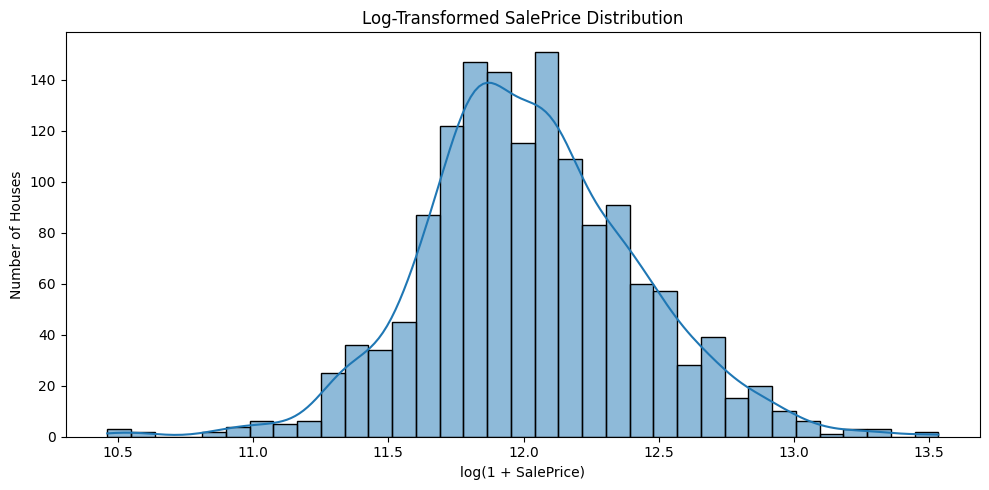


PREPROCESSING SUMMARY
Original features       : 80
Features after cleaning : 83
Training samples        : 1460
Missing values          : 0

Engineered features:
  ✓ TotalSF
  ✓ TotalBathrooms
  ✓ TotalPorchSF
  ✓ TotalPropertyArea

Target transformation:
SalePrice → log1p(SalePrice)

✅ DATA CLEANING & FEATURE ENGINEERING COMPLETED


In [7]:
# ============================================================
# BLOCK 3 — DATA CLEANING & FEATURE ENGINEERING
# ============================================================

print("=" * 65)
print("DATA CLEANING & FEATURE ENGINEERING")
print("=" * 65)

# ------------------------------------------------------------
# 1. Create a copy for preprocessing
# ------------------------------------------------------------

df_clean = df.copy()

print("\nOriginal dataset shape:")
print(df_clean.shape)


# ------------------------------------------------------------
# 2. Separate target variable
# ------------------------------------------------------------

target = "SalePrice"

X = df_clean.drop(columns=[target])
y = df_clean[target]


# ------------------------------------------------------------
# 3. Identify numerical and categorical columns
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical features   :", len(numeric_features))
print("Categorical features :", len(categorical_features))


# ------------------------------------------------------------
# 4. Analyze missing values
# ------------------------------------------------------------

missing = X.isnull().sum()

missing = missing[
    missing > 0
].sort_values(
    ascending=False
)

print("\nTop columns with missing values:")
display(missing.head(20).to_frame("Missing Values"))


# ------------------------------------------------------------
# 5. Remove ID column
# ------------------------------------------------------------

if "Id" in X.columns:
    X = X.drop(columns=["Id"])
    print("\n✅ ID column removed.")


# ------------------------------------------------------------
# 6. Re-identify feature types after removing ID
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# ------------------------------------------------------------
# 7. Handle numerical missing values
# ------------------------------------------------------------

# For numerical variables, use the median.
# Median is robust against extreme values.

for column in numeric_features:
    if X[column].isnull().sum() > 0:
        X[column] = X[column].fillna(
            X[column].median()
        )


# ------------------------------------------------------------
# 8. Handle categorical missing values
# ------------------------------------------------------------

# For categorical variables, use the most frequent category.

for column in categorical_features:
    if X[column].isnull().sum() > 0:
        mode_value = X[column].mode()

        if len(mode_value) > 0:
            X[column] = X[column].fillna(
                mode_value[0]
            )
        else:
            X[column] = X[column].fillna("Missing")


# ------------------------------------------------------------
# 9. Verify missing values
# ------------------------------------------------------------

remaining_missing = X.isnull().sum().sum()

print("\nRemaining missing values:")
print(remaining_missing)

if remaining_missing == 0:
    print("✅ Missing values successfully handled.")
else:
    print("⚠️ Some missing values still remain.")


# ------------------------------------------------------------
# 10. Feature Engineering
# ------------------------------------------------------------

print("\nCreating additional features...")


# Total usable living area
if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(X.columns):
    X["TotalSF"] = (
        X["TotalBsmtSF"]
        + X["1stFlrSF"]
        + X["2ndFlrSF"]
    )


# Total bathrooms with partial bathrooms weighted as 0.5
if {
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath"
}.issubset(X.columns):

    X["TotalBathrooms"] = (
        X["FullBath"]
        + 0.5 * X["HalfBath"]
        + X["BsmtFullBath"]
        + 0.5 * X["BsmtHalfBath"]
    )


# Total porch/deck area
porch_features = [
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "WoodDeckSF"
]

available_porch_features = [
    column for column in porch_features
    if column in X.columns
]

if available_porch_features:
    X["TotalPorchSF"] = X[
        available_porch_features
    ].sum(axis=1)


# Total overall house area
area_features = [
    "GrLivArea",
    "TotalBsmtSF",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF"
]

available_area_features = [
    column for column in area_features
    if column in X.columns
]

if available_area_features:
    X["TotalPropertyArea"] = X[
        available_area_features
    ].sum(axis=1)


# ------------------------------------------------------------
# 11. Log-transform target variable
# ------------------------------------------------------------

# SalePrice is right-skewed.
# Log transformation can make the target distribution
# easier for regression models to learn.

y_log = np.log1p(y)


# ------------------------------------------------------------
# 12. Compare original and transformed target
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    y_log,
    kde=True
)

plt.title("Log-Transformed SalePrice Distribution")
plt.xlabel("log(1 + SalePrice)")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Final preprocessing summary
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PREPROCESSING SUMMARY")
print("=" * 65)

print(f"Original features       : {df.shape[1] - 1}")
print(f"Features after cleaning : {X.shape[1]}")
print(f"Training samples        : {X.shape[0]}")
print(f"Missing values          : {X.isnull().sum().sum()}")

print("\nEngineered features:")

engineered_features = [
    feature
    for feature in [
        "TotalSF",
        "TotalBathrooms",
        "TotalPorchSF",
        "TotalPropertyArea"
    ]
    if feature in X.columns
]

for feature in engineered_features:
    print(f"  ✓ {feature}")

print("\nTarget transformation:")
print("SalePrice → log1p(SalePrice)")

print("\n✅ DATA CLEANING & FEATURE ENGINEERING COMPLETED")

In [8]:
# ============================================================
# BLOCK 4 + 5
# TRAIN/TEST SPLIT + PREPROCESSING + MODEL TRAINING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

print("=" * 70)
print("TRAIN / TEST SPLIT + PREPROCESSING + MODEL TRAINING")
print("=" * 70)


# ============================================================
# 1. REBUILD FEATURES FROM ORIGINAL DATA
#    This ensures preprocessing does not leak test information.
# ============================================================

data = df.copy()

# Separate target
X = data.drop(columns=["SalePrice"]).copy()
y = data["SalePrice"].copy()

# Remove ID because it does not represent a meaningful property feature
if "Id" in X.columns:
    X = X.drop(columns=["Id"])

# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(X.columns):
    X["TotalSF"] = (
        X["TotalBsmtSF"]
        + X["1stFlrSF"]
        + X["2ndFlrSF"]
    )

if {
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath"
}.issubset(X.columns):

    X["TotalBathrooms"] = (
        X["FullBath"]
        + 0.5 * X["HalfBath"]
        + X["BsmtFullBath"]
        + 0.5 * X["BsmtHalfBath"]
    )

porch_features = [
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "WoodDeckSF"
]

available_porch = [
    col for col in porch_features
    if col in X.columns
]

if available_porch:
    X["TotalPorchSF"] = X[available_porch].sum(axis=1)

# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n📌 Dataset Split")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


# ============================================================
# 4. IDENTIFY FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"\nNumerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")


# ============================================================
# 5. NUMERICAL PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 6. CATEGORICAL PREPROCESSING
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 7. COMBINE PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ============================================================
# 8. LOG TRANSFORM TARGET
# ============================================================

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("\n✅ Target transformed using log1p().")


# ============================================================
# 9. DEFINE MODELS
# ============================================================

models = {

    "Ridge Regression": Ridge(
        alpha=10.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}


# ============================================================
# 10. TRAIN AND EVALUATE MODELS
# ============================================================

results = []
trained_models = {}

for model_name, model in models.items():

    print("\n" + "-" * 70)
    print(f"Training: {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train_log
    )

    # Predict log prices
    predictions_log = pipeline.predict(X_test)

    # Convert predictions back to original price scale
    predictions = np.expm1(predictions_log)

    # Prevent negative predictions
    predictions = np.maximum(predictions, 0)

    # Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    # RMSLE
    rmsle = np.sqrt(
        mean_squared_error(
            np.log1p(y_test),
            np.log1p(predictions)
        )
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "RMSLE": rmsle,
        "R2 Score": r2
    })

    trained_models[model_name] = pipeline

    print(f"MAE   : ${mae:,.2f}")
    print(f"RMSE  : ${rmse:,.2f}")
    print(f"RMSLE : {rmsle:.4f}")
    print(f"R²    : {r2:.4f}")


# ============================================================
# 11. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSLE",
    ascending=True
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.style.format({
        "MAE": "${:,.2f}",
        "RMSE": "${:,.2f}",
        "RMSLE": "{:.4f}",
        "R2 Score": "{:.4f}"
    })
)


# ============================================================
# 12. SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("\n🏆 BEST MODEL")
print(f"Model : {best_model_name}")

print("\nBest model performance:")

best_result = results_df.iloc[0]

print(f"MAE   : ${best_result['MAE']:,.2f}")
print(f"RMSE  : ${best_result['RMSE']:,.2f}")
print(f"RMSLE : {best_result['RMSLE']:.4f}")
print(f"R²    : {best_result['R2 Score']:.4f}")

print("\n✅ MODEL TRAINING COMPLETED")

TRAIN / TEST SPLIT + PREPROCESSING + MODEL TRAINING

📌 Dataset Split
Training samples : 1168
Testing samples  : 292

Numerical features   : 39
Categorical features : 43

✅ Target transformed using log1p().

----------------------------------------------------------------------
Training: Ridge Regression
MAE   : $16,407.40
RMSE  : $25,045.84
RMSLE : 0.1361
R²    : 0.9182

----------------------------------------------------------------------
Training: Random Forest
MAE   : $17,376.26
RMSE  : $30,324.38
RMSLE : 0.1462
R²    : 0.8801

----------------------------------------------------------------------
Training: Gradient Boosting
MAE   : $15,886.78
RMSE  : $28,195.01
RMSLE : 0.1360
R²    : 0.8964

----------------------------------------------------------------------
Training: Hist Gradient Boosting
MAE   : $16,361.51
RMSE  : $29,120.47
RMSLE : 0.1398
R²    : 0.8894

MODEL COMPARISON


,Model,MAE,RMSE,RMSLE,R2 Score
0,Gradient Boosting,"$15,886.78","$28,195.01",0.1360,0.8964
1,Ridge Regression,"$16,407.40","$25,045.84",0.1361,0.9182
2,Hist Gradient Boosting,"$16,361.51","$29,120.47",0.1398,0.8894
3,Random Forest,"$17,376.26","$30,324.38",0.1462,0.8801



🏆 BEST MODEL
Model : Gradient Boosting

Best model performance:
MAE   : $15,886.78
RMSE  : $28,195.01
RMSLE : 0.1360
R²    : 0.8964

✅ MODEL TRAINING COMPLETED


In [9]:
# ============================================================
# BLOCK 6 — HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

print("=" * 70)
print("HYPERPARAMETER TUNING")
print("=" * 70)

print(f"\nCurrent best model: {best_model_name}")


# ============================================================
# TUNING — GRADIENT BOOSTING / RANDOM FOREST
# ============================================================

if best_model_name == "Gradient Boosting":

    tuning_model = GradientBoostingRegressor(
        random_state=42
    )

    param_distributions = {
        "model__n_estimators": randint(200, 600),
        "model__learning_rate": uniform(0.02, 0.08),
        "model__max_depth": randint(2, 5),
        "model__min_samples_split": randint(2, 10),
        "model__min_samples_leaf": randint(1, 5)
    }


elif best_model_name == "Random Forest":

    tuning_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    param_distributions = {
        "model__n_estimators": randint(200, 500),
        "model__max_depth": randint(10, 30),
        "model__min_samples_split": randint(2, 10),
        "model__min_samples_leaf": randint(1, 5),
        "model__max_features": ["sqrt", "log2", 0.7, 1.0]
    }


elif best_model_name == "Hist Gradient Boosting":

    tuning_model = HistGradientBoostingRegressor(
        random_state=42
    )

    param_distributions = {
        "model__max_iter": randint(200, 500),
        "model__learning_rate": uniform(0.02, 0.08),
        "model__max_leaf_nodes": randint(15, 50),
        "model__min_samples_leaf": randint(10, 30),
        "model__l2_regularization": uniform(0.0, 1.0)
    }


else:

    # Ridge fallback
    tuning_model = Ridge()

    param_distributions = {
        "model__alpha": uniform(0.1, 50)
    }


# ============================================================
# BUILD TUNING PIPELINE
# ============================================================

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tuning_model)
    ]
)


# ============================================================
# RANDOMIZED SEARCH
# ============================================================

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="neg_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\n🔎 Searching for better hyperparameters...")
print("This may take a few minutes.")

random_search.fit(
    X_train,
    y_train_log
)


# ============================================================
# BEST PARAMETERS
# ============================================================

print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS")
print("=" * 70)

print("\n")
for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")


# ============================================================
# FINAL TUNED MODEL
# ============================================================

final_model = random_search.best_estimator_

predictions_log = final_model.predict(X_test)

predictions = np.expm1(predictions_log)

# Prevent negative predictions
predictions = np.maximum(predictions, 0)


# ============================================================
# FINAL EVALUATION
# ============================================================

final_mae = mean_absolute_error(
    y_test,
    predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

final_r2 = r2_score(
    y_test,
    predictions
)

final_rmsle = np.sqrt(
    mean_squared_error(
        np.log1p(y_test),
        np.log1p(predictions)
    )
)


print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(f"\nModel : Tuned {best_model_name}")

print(f"\nMAE   : ${final_mae:,.2f}")
print(f"RMSE  : ${final_rmse:,.2f}")
print(f"RMSLE : {final_rmsle:.4f}")
print(f"R²    : {final_r2:.4f}")

print("\n✅ HYPERPARAMETER TUNING COMPLETED")

HYPERPARAMETER TUNING

Current best model: Gradient Boosting

🔎 Searching for better hyperparameters...
This may take a few minutes.
Fitting 5 folds for each of 15 candidates, totalling 75 fits

BEST HYPERPARAMETERS


model__learning_rate: 0.05083332020319329
model__max_depth: 3
model__min_samples_leaf: 1
model__min_samples_split: 3
model__n_estimators: 539

FINAL MODEL PERFORMANCE

Model : Tuned Gradient Boosting

MAE   : $15,881.57
RMSE  : $28,505.38
RMSLE : 0.1359
R²    : 0.8941

✅ HYPERPARAMETER TUNING COMPLETED


MODEL ERROR ANALYSIS

📌 Sample Predictions


,Actual Price,Predicted Price,Absolute Error,Percentage Error
0,"$154,500","$143,819","$10,681",6.91%
1,"$325,000","$356,643","$31,643",9.74%
2,"$115,000","$113,299","$1,701",1.48%
3,"$159,000","$153,531","$5,469",3.44%
4,"$315,500","$336,229","$20,729",6.57%
5,"$75,500","$79,795","$4,295",5.69%
6,"$311,500","$235,518","$75,982",24.39%
7,"$146,000","$144,299","$1,701",1.17%
8,"$84,500","$78,009","$6,491",7.68%
9,"$135,500","$137,815","$2,315",1.71%


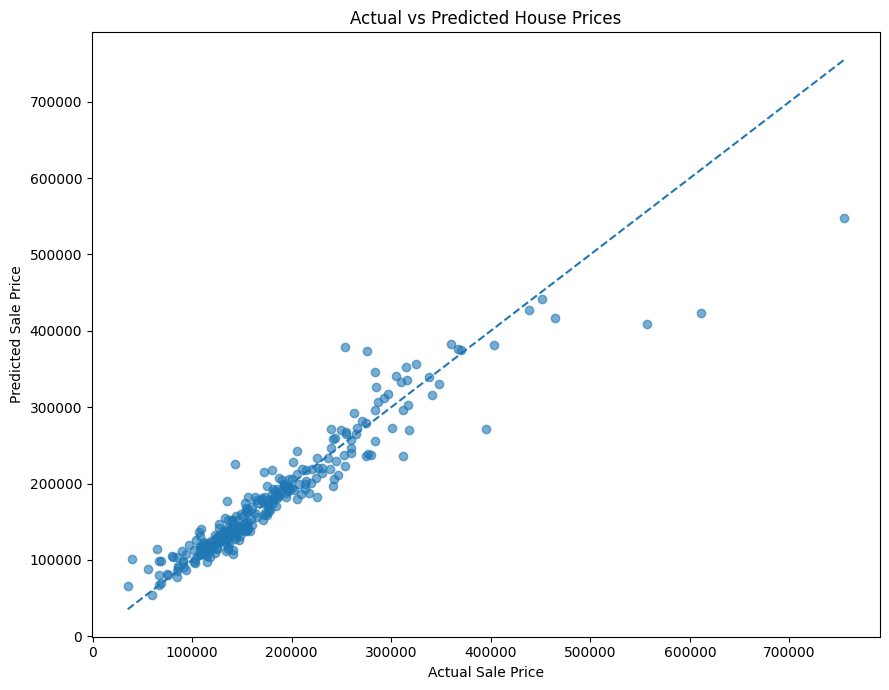

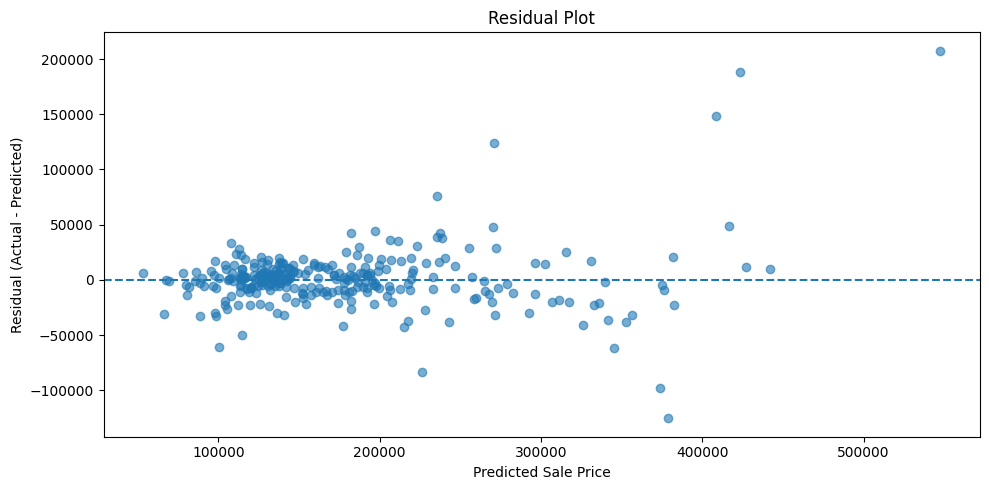


📌 10 Largest Prediction Errors


,Actual Price,Predicted Price,Absolute Error,Percentage Error
139,"$755,000","$547,487","$207,513",27.49%
74,"$611,657","$423,413","$188,244",30.78%
168,"$556,581","$408,432","$148,149",26.62%
43,"$253,293","$378,528","$125,235",49.44%
260,"$395,000","$270,887","$124,113",31.42%
167,"$276,000","$373,856","$97,856",35.45%
278,"$143,000","$226,024","$83,024",58.06%
6,"$311,500","$235,518","$75,982",24.39%
119,"$284,000","$345,505","$61,505",21.66%
197,"$40,000","$100,572","$60,572",151.43%



ERROR ANALYSIS COMPLETED ✅


In [10]:
# ============================================================
# BLOCK 7 — ACTUAL vs PREDICTED + ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("MODEL ERROR ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Create prediction dataframe
# ------------------------------------------------------------

prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

prediction_df["Absolute Error"] = (
    prediction_df["Actual Price"]
    - prediction_df["Predicted Price"]
).abs()

prediction_df["Percentage Error"] = (
    prediction_df["Absolute Error"]
    / prediction_df["Actual Price"]
) * 100

print("\n📌 Sample Predictions")
display(
    prediction_df.head(10).style.format({
        "Actual Price": "${:,.0f}",
        "Predicted Price": "${:,.0f}",
        "Absolute Error": "${:,.0f}",
        "Percentage Error": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Actual vs Predicted Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

# Perfect prediction line
min_price = min(y_test.min(), predictions.min())
max_price = max(y_test.max(), predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Residual Analysis
# ------------------------------------------------------------

residuals = y_test.values - predictions

plt.figure(figsize=(10, 5))

plt.scatter(
    predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Largest prediction errors
# ------------------------------------------------------------

print("\n📌 10 Largest Prediction Errors")

largest_errors = (
    prediction_df
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .head(10)
)

display(
    largest_errors.style.format({
        "Actual Price": "${:,.0f}",
        "Predicted Price": "${:,.0f}",
        "Absolute Error": "${:,.0f}",
        "Percentage Error": "{:.2f}%"
    })
)


print("\n" + "=" * 70)
print("ERROR ANALYSIS COMPLETED ✅")
print("=" * 70)

In [11]:
# ============================================================
# BLOCK 8 — INTERACTIVE HOUSE PRICE PREDICTOR
# ============================================================

!pip -q install gradio

import gradio as gr
import pandas as pd
import numpy as np


# ============================================================
# 1. CREATE DEFAULT VALUES FOR ALL MODEL FEATURES
# ============================================================

# Start with one row using training-data defaults
default_values = {}

for column in X_train.columns:

    if column in numeric_features:
        default_values[column] = X_train[column].median()

    else:
        mode_value = X_train[column].mode()

        if len(mode_value) > 0:
            default_values[column] = mode_value.iloc[0]
        else:
            default_values[column] = "Missing"


# ============================================================
# 2. PREDICTION FUNCTION
# ============================================================

def predict_house_price(
    overall_qual,
    gr_liv_area,
    garage_cars,
    total_bsmt_sf,
    year_built,
    full_bath,
    neighborhood
):

    # Create a copy of default values
    house = default_values.copy()

    # --------------------------------------------------------
    # Update user-provided features
    # --------------------------------------------------------

    if "OverallQual" in house:
        house["OverallQual"] = overall_qual

    if "GrLivArea" in house:
        house["GrLivArea"] = gr_liv_area

    if "GarageCars" in house:
        house["GarageCars"] = garage_cars

    if "TotalBsmtSF" in house:
        house["TotalBsmtSF"] = total_bsmt_sf

    if "YearBuilt" in house:
        house["YearBuilt"] = year_built

    if "FullBath" in house:
        house["FullBath"] = full_bath

    if "Neighborhood" in house:
        house["Neighborhood"] = neighborhood

    # --------------------------------------------------------
    # Recalculate engineered features
    # --------------------------------------------------------

    if {
        "TotalBsmtSF",
        "1stFlrSF",
        "2ndFlrSF"
    }.issubset(house.keys()):

        house["TotalSF"] = (
            house["TotalBsmtSF"]
            + house["1stFlrSF"]
            + house["2ndFlrSF"]
        )

    if {
        "FullBath",
        "HalfBath",
        "BsmtFullBath",
        "BsmtHalfBath"
    }.issubset(house.keys()):

        house["TotalBathrooms"] = (
            house["FullBath"]
            + 0.5 * house["HalfBath"]
            + house["BsmtFullBath"]
            + 0.5 * house["BsmtHalfBath"]
        )

    if {
        "OpenPorchSF",
        "EnclosedPorch",
        "3SsnPorch",
        "ScreenPorch",
        "WoodDeckSF"
    }.issubset(house.keys()):

        house["TotalPorchSF"] = (
            house["OpenPorchSF"]
            + house["EnclosedPorch"]
            + house["3SsnPorch"]
            + house["ScreenPorch"]
            + house["WoodDeckSF"]
        )

    # --------------------------------------------------------
    # Create dataframe
    # --------------------------------------------------------

    input_df = pd.DataFrame([house])

    # Ensure exact feature order
    input_df = input_df[X_train.columns]

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    predicted_log_price = final_model.predict(input_df)[0]

    predicted_price = np.expm1(predicted_log_price)

    return f"🏠 Estimated House Price: ${predicted_price:,.0f}"


# ============================================================
# 3. GRADIO INTERFACE
# ============================================================

neighborhood_choices = sorted(
    X_train["Neighborhood"].dropna().unique().tolist()
) if "Neighborhood" in X_train.columns else []


demo = gr.Interface(

    fn=predict_house_price,

    inputs=[

        gr.Slider(
            minimum=1,
            maximum=10,
            value=6,
            step=1,
            label="Overall Quality (1–10)"
        ),

        gr.Slider(
            minimum=500,
            maximum=5000,
            value=1500,
            step=50,
            label="Living Area (sq ft)"
        ),

        gr.Slider(
            minimum=0,
            maximum=4,
            value=2,
            step=1,
            label="Garage Capacity (cars)"
        ),

        gr.Slider(
            minimum=0,
            maximum=3000,
            value=800,
            step=50,
            label="Basement Area (sq ft)"
        ),

        gr.Slider(
            minimum=1870,
            maximum=2010,
            value=2000,
            step=1,
            label="Year Built"
        ),

        gr.Slider(
            minimum=0,
            maximum=4,
            value=2,
            step=1,
            label="Full Bathrooms"
        ),

        gr.Dropdown(
            choices=neighborhood_choices,
            value=(
                neighborhood_choices[0]
                if neighborhood_choices
                else None
            ),
            label="Neighborhood"
        )
    ],

    outputs=gr.Textbox(
        label="Predicted House Price"
    ),

    title="🏠 House Price Prediction System",

    description=(
        "Machine Learning based house price prediction "
        "using regression models, feature engineering, "
        "and a tuned final model."
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://182deb9ada9cadacb5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
# ============================================================
# BLOCK 9 — SAVE FINAL MODEL
# ============================================================

import joblib
import os

os.makedirs(
    "house_price_model",
    exist_ok=True
)

# Save complete preprocessing + model pipeline
joblib.dump(
    final_model,
    "house_price_model/house_price_prediction_pipeline.pkl"
)

# Save feature information
joblib.dump(
    X_train.columns.tolist(),
    "house_price_model/model_features.pkl"
)

print("=" * 65)
print("MODEL SAVING")
print("=" * 65)

print("\n✅ Final model saved successfully!")

print("\nSaved files:")

for file in os.listdir("house_price_model"):
    file_path = os.path.join(
        "house_price_model",
        file
    )

    size_kb = os.path.getsize(file_path) / 1024

    print(
        f"  ✓ {file} — {size_kb:.2f} KB"
    )


# ------------------------------------------------------------
# Verify model can be loaded
# ------------------------------------------------------------

loaded_model = joblib.load(
    "house_price_model/house_price_prediction_pipeline.pkl"
)

print("\n✅ Model successfully loaded for verification.")

print("\nModel type:")
print(type(loaded_model))

print("\n🎉 MODEL SAVING COMPLETED")

MODEL SAVING

✅ Final model saved successfully!

Saved files:
  ✓ model_features.pkl — 1.03 KB
  ✓ house_price_prediction_pipeline.pkl — 669.80 KB

✅ Model successfully loaded for verification.

Model type:
<class 'sklearn.pipeline.Pipeline'>

🎉 MODEL SAVING COMPLETED


In [13]:
# ============================================================
# BLOCK 10 — ZIP MODEL FILES
# ============================================================

!zip -r house_price_model.zip house_price_model

print("\n✅ Model package created:")
print("house_price_model.zip")

  adding: house_price_model/ (stored 0%)
  adding: house_price_model/model_features.pkl (deflated 46%)
  adding: house_price_model/house_price_prediction_pipeline.pkl (deflated 74%)

✅ Model package created:
house_price_model.zip
